In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
#Display/Plotting defaults
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 100
SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']  # chronological cropping seasons in India

In [3]:
DATA_PATH = 'seasonal_agriculture_performance_dataset.csv'  # path to the data folder
df = pd.read_csv(DATA_PATH)  # read the dataset into a pandas DataFrame
df['Season'] = pd.Categorical(df['Season'],categories=SEASON_ORDER,ordered=True) #set the order of the cropping seasons for plotting purposes
print(f"Data loaded successfully.Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
df.head() #Display the first few rows of the dataset
df.info() #Display th summary of the dataset including data types and non-null counts
df.describe().T #Deisplay the summanry characteristics of the dataset's numerical columns


Data loaded successfully.Dataset contains 4000 rows and 28 columns.
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Farm_ID                        4000 non-null   str     
 1   State                          4000 non-null   str     
 2   District                       4000 non-null   str     
 3   Crop                           4000 non-null   str     
 4   Season                         4000 non-null   category
 5   Farm_Area_Hectares             4000 non-null   float64 
 6   Rainfall_mm                    3952 non-null   float64 
 7   Avg_Temperature_C              4000 non-null   float64 
 8   Humidity_pct                   4000 non-null   float64 
 9   Sunlight_Hours_Day             4000 non-null   float64 
 10  Soil_pH                        4000 non-null   float64 
 11  Soil_Moisture_pct              3960 no

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [4]:
categorical_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
for c in categorical_cols:
       print(f"{c} ({df[c].nunique()} unique): {sorted(df[c].dropna().unique().tolist())}\n")

State (8 unique): ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']

District (10 unique): ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']

Crop (8 unique): ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']

Season (3 unique): ['Kharif', 'Rabi', 'Zaid']

Irrigation_Method (4 unique): ['Drip', 'Flood', 'Rainfed', 'Sprinkler']



In [5]:
missing = df.isnull().sum()
missing =missing[missing>0].sort_values(ascending=False)

missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Values': missing, 'Percentage': missing_pct})


,Missing Values,Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [6]:
for col in ['Rainfall_mm' , 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season' , observed = True)[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values after imputation:", df.isnull().sum().sum())

dupes  = df.duplicated().sum()
print(f"Duplicate rows in the dataset: {dupes}")
if dupes:
    df = df.drop_duplicates()
    print(f"Dropped Duplicates")

Remaining missing values after imputation: 0
Duplicate rows in the dataset: 0


In [7]:
def iqr_outlier_summary(frame,cols):
    rows = []
    for c in cols:
        q1,q3 = frame[c].quantile([0.25,0.75])
        iqr = q3-q1
        lo,hi = q1-1.5*iqr, q3+1.5*iqr
        n_out = int(((frame[c] < lo) | (frame[c] > hi)).sum())
        rows.append([c, round(lo, 2), round(hi, 2), n_out, round(n_out / len(frame) * 100, 1)])
    return pd.DataFrame(rows, columns=['column', 'lower_bound', 'upper_bound', 'n_outliers', 'pct_outliers'])
check_cols = ['Yield_Tonnes_Ha', 'Rainfall_mm', 'Profit_INR' , 'Water_Used_m3']
iqr_outlier_summary(df, check_cols)


,column,lower_bound,upper_bound,n_outliers,pct_outliers
0,Yield_Tonnes_Ha,-1.62,5.50,302,7.5
1,Rainfall_mm,-328.12,1534.67,0,0.0
2,Profit_INR,-696111.00,763567.00,404,10.1
3,Water_Used_m3,-6072.75,16171.25,276,6.9


In [8]:
for col in ['Yield_Tonnes_Ha', 'Production_Tonnes']:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lo, hi)
 
df[['Yield_Tonnes_Ha', 'Production_Tonnes']].describe().T[['min', 'max', 'mean']]


,min,max,mean
Yield_Tonnes_Ha,0.3000,70.8201,5.157414
Production_Tonnes,0.4999,701.5908,41.385839


In [9]:
df['Profit_Margin_pct'] = np.where(df['Revenue_INR'] > 0, (df['Profit_INR'] / df['Revenue_INR']) * 100, np.nan)
df['Cost_per_Tonne_INR'] = np.where(df['Production_Tonnes'] > 0, df['Total_Cost_INR'] / df['Production_Tonnes'], np.nan)
df['Is_Profitable'] = df['Profit_INR'] > 0

df[['Profit_Margin_pct', 'Cost_per_Tonne_INR', 'Is_Profitable']].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Profit_Margin_pct,4000.0,NaN,NaN,NaN,-45.492178,158.085472,-1461.851219,-60.192762,1.146236,32.885876,85.92122
Cost_per_Tonne_INR,4000.0,NaN,NaN,NaN,55067.629404,53213.176473,568.357511,23032.641975,37897.601738,64128.28313,296805.128205
Is_Profitable,4000,2,True,2034,NaN,NaN,NaN,NaN,NaN,NaN,NaN


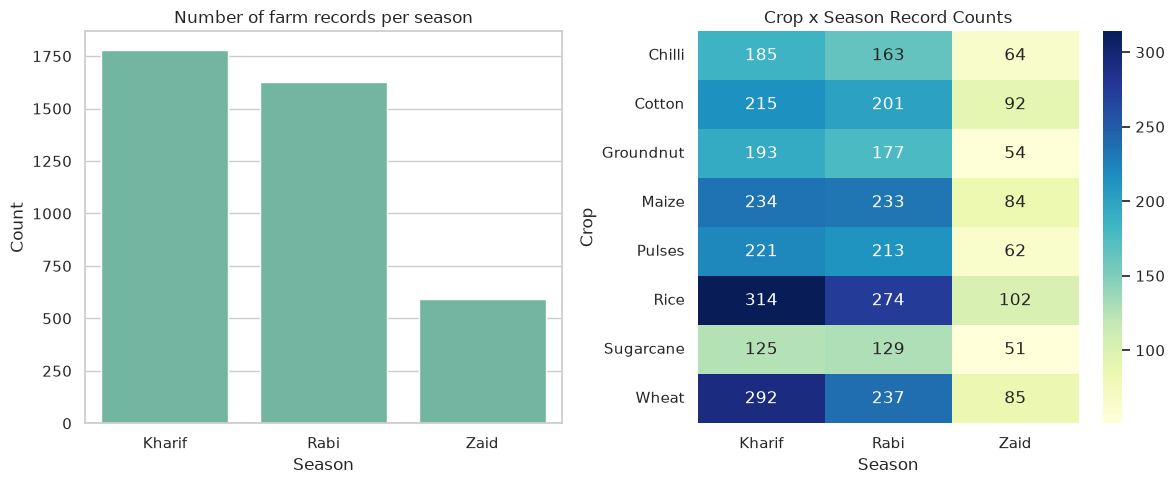

In [10]:
fig , axes = plt.subplots(1,2,figsize=(12,5))

season_counts = df['Season'].value_counts().reindex(SEASON_ORDER)
sns.barplot(x=season_counts.index,y = season_counts.values,ax = axes[0])
axes[0].set_title('Number of farm records per season')
axes[0].set_ylabel('Count')

crop_season = pd.crosstab(df['Crop'],df['Season'])
sns.heatmap(crop_season,annot=True,fmt='d',cmap='YlGnBu',ax=axes[1])
axes[1].set_title('Crop x Season Record Counts')
 
plt.tight_layout()
plt.show()
 


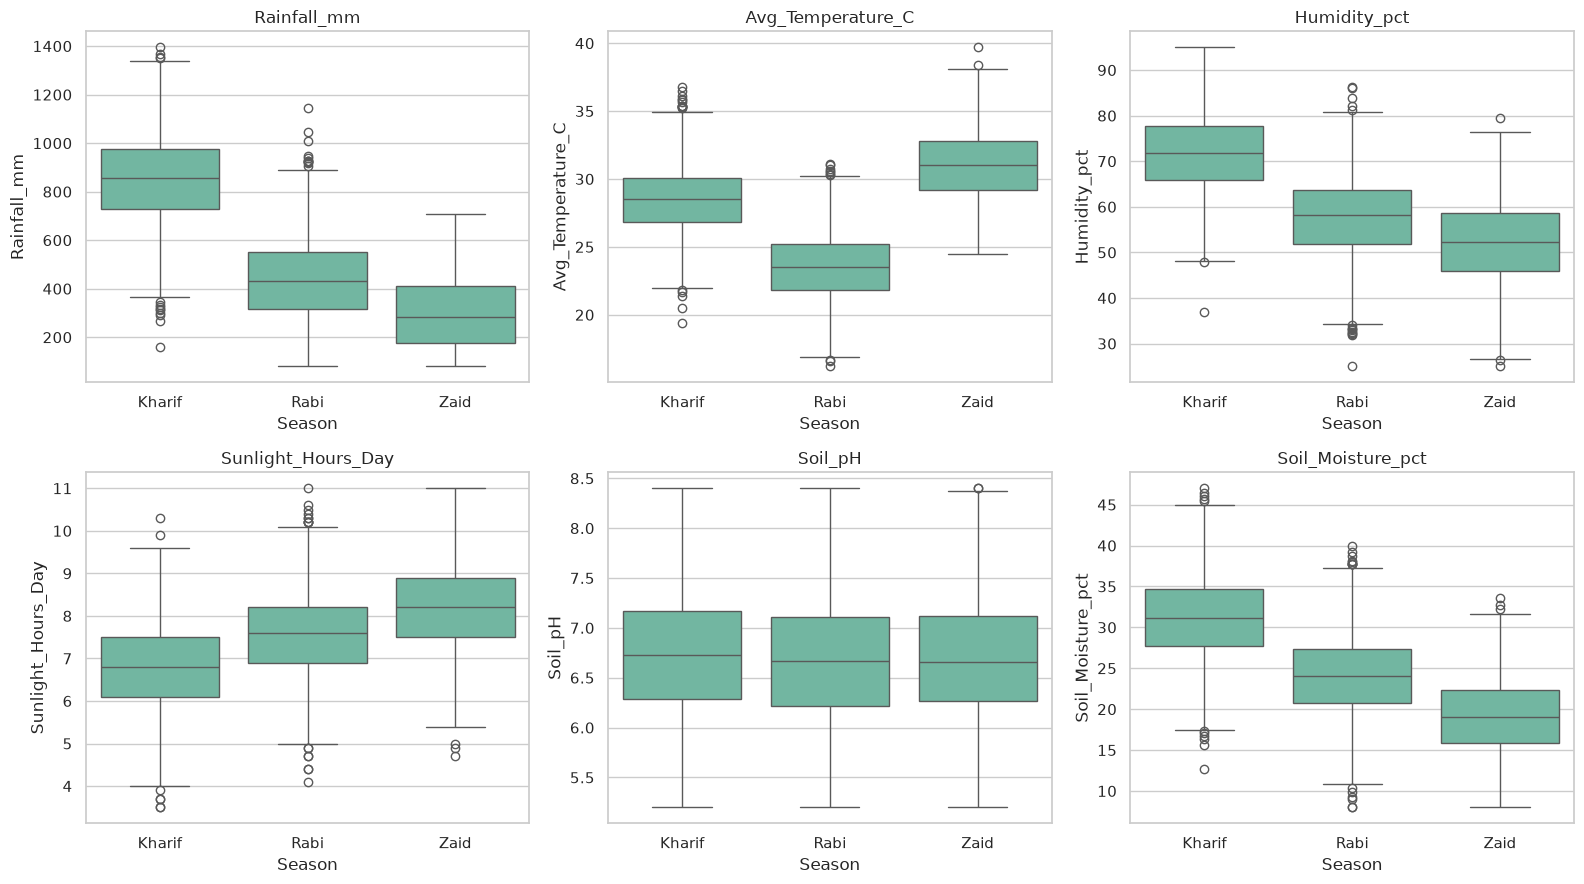

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,852.11,28.45,71.81,6.79,6.73,31.20
Rabi,435.94,23.49,57.89,7.59,6.67,24.05
Zaid,299.12,31.04,52.01,8.18,6.69,19.17


In [11]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct']
 
fig, axes = plt.subplots(2,3,figsize=(16,9))
for ax, col in zip(axes.flatten(),env_cols):
    sns.boxplot(data=df,x='Season', y=col, order=SEASON_ORDER, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

df.groupby('Season', observed=True)[env_cols].mean().round(2)
 


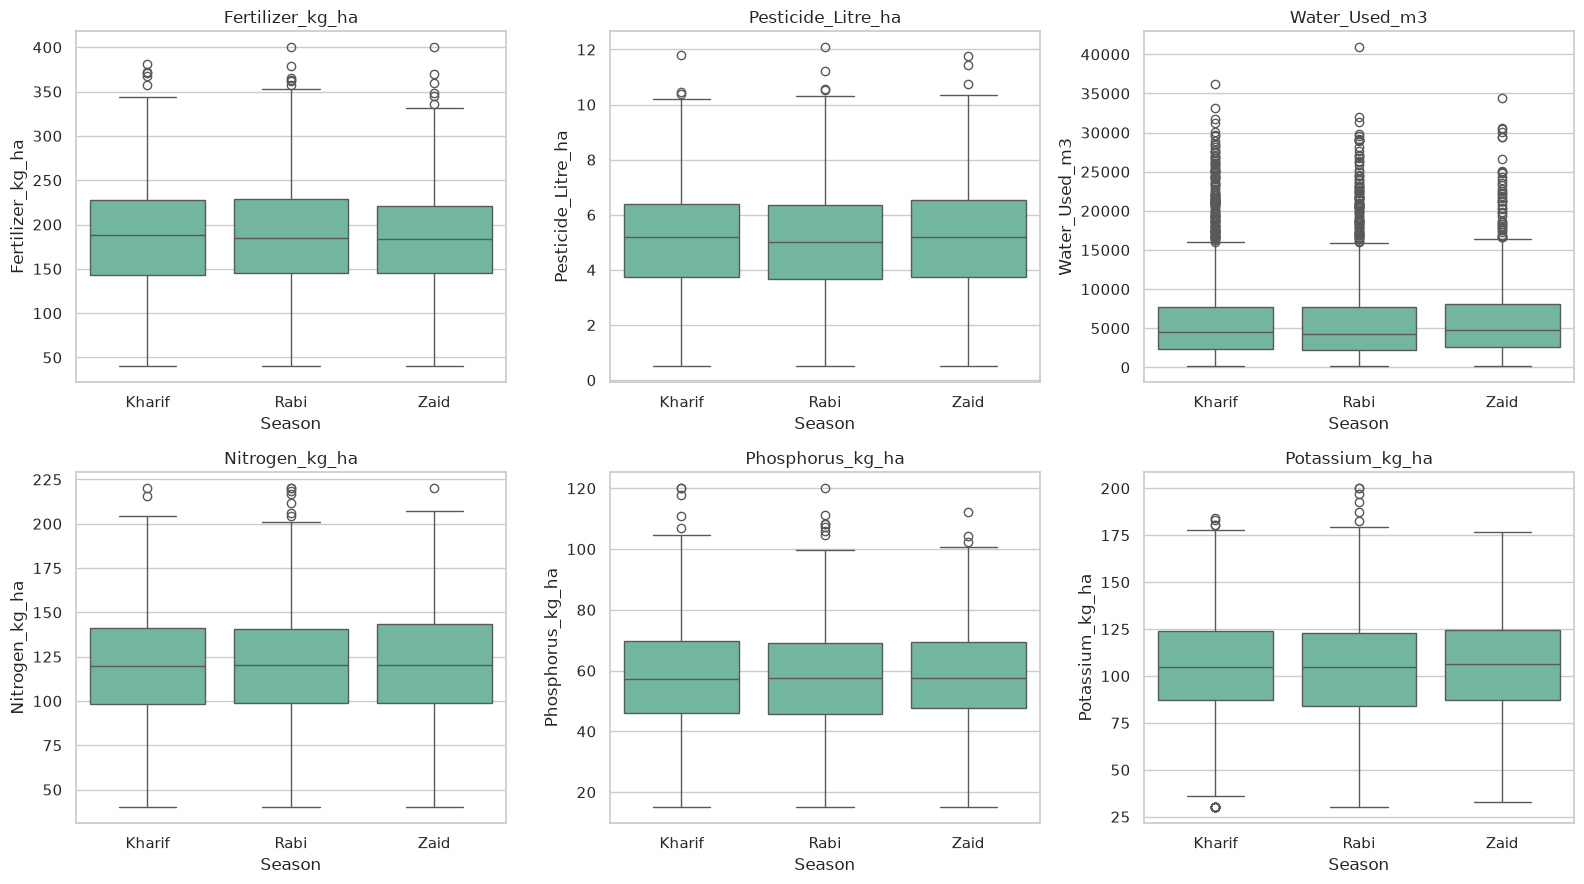

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,,
Kharif,187.08,5.08,6102.20,120.02,58.10,105.30
Rabi,185.41,5.02,5846.99,120.40,57.31,103.93
Zaid,184.64,5.17,6419.89,120.53,58.13,105.42


In [12]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha']
 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, resource_cols):
    sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
 
df.groupby('Season', observed=True)[resource_cols].mean().round(2)


In [13]:
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'], margins=True, margins_name='Total')
irrigation_season.round(2)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler,Total
Season,,,,,
Kharif,405,590,463,321,1779
Rabi,370,526,438,293,1627
Zaid,140,194,140,120,594
Total,915,1310,1041,734,4000


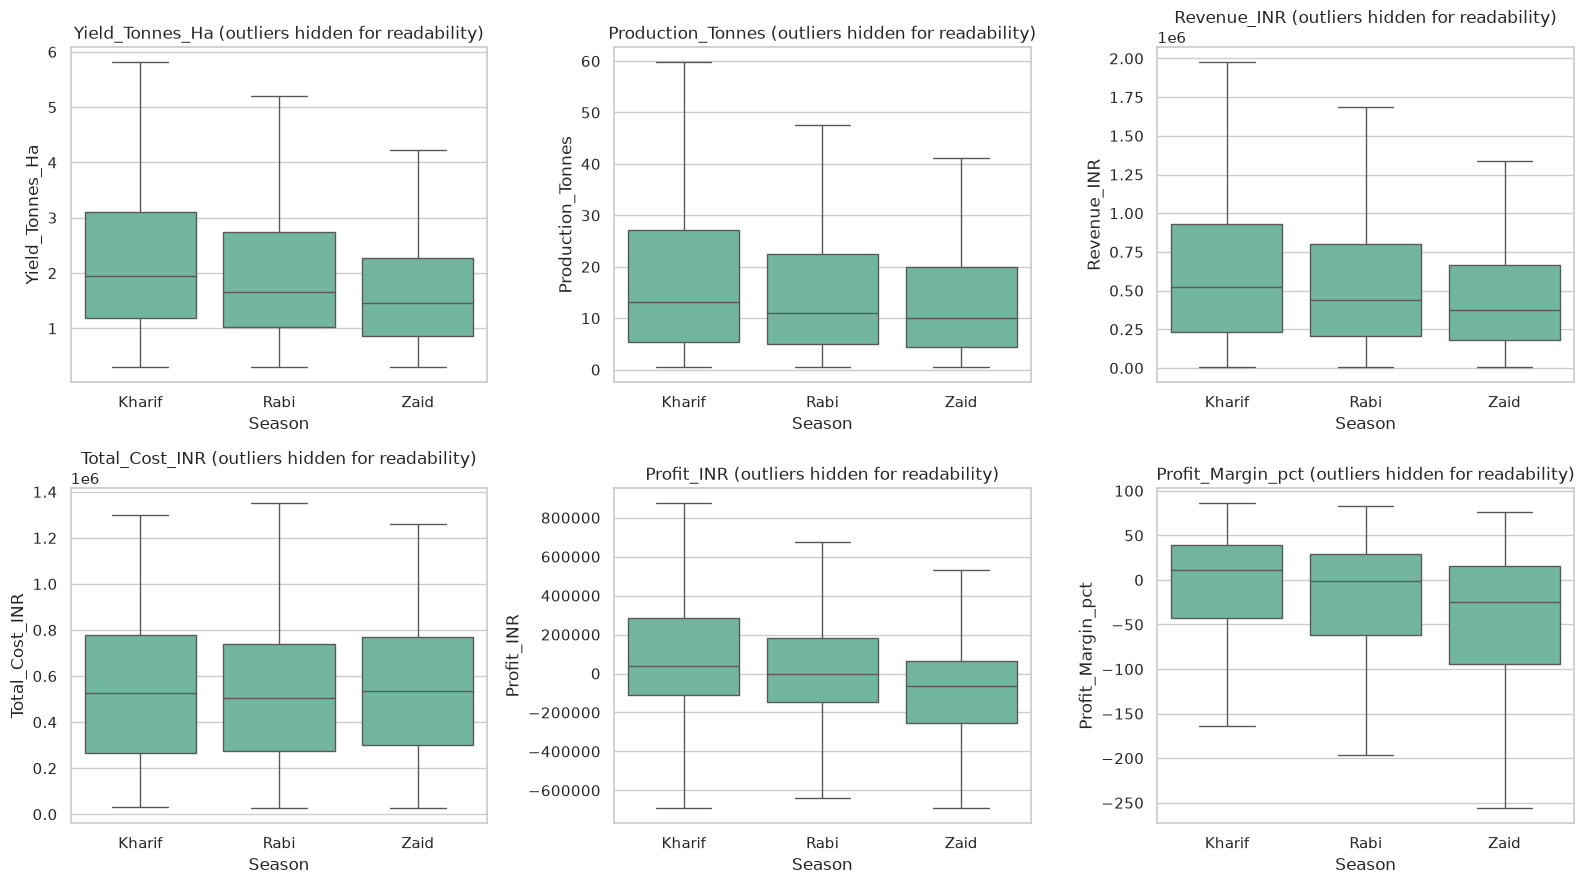

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct
Season,,,,,,
Kharif,5.50,43.79,710719.06,531804.41,178914.65,-38.64
Rabi,4.98,39.90,601526.05,513836.58,87689.47,-44.27
Zaid,4.64,38.27,519171.90,543976.73,-24804.82,-69.35


In [14]:
econ_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR', 'Total_Cost_INR', 'Profit_INR', 'Profit_Margin_pct']
 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, econ_cols):
    sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, ax=ax, showfliers=False)
    ax.set_title(col + ' (outliers hidden for readability)')
plt.tight_layout()
plt.show()
 
season_econ = df.groupby('Season', observed=True)[econ_cols].mean().round(2)
season_econ
 


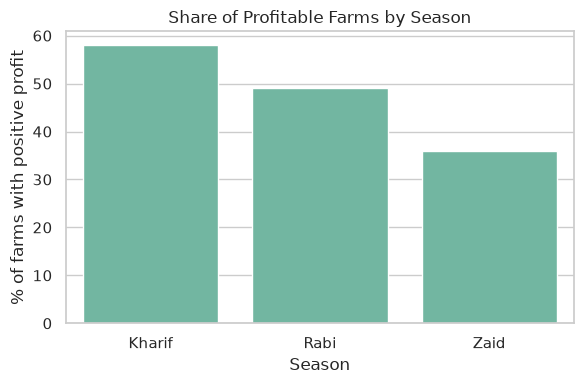

Season
Kharif    58.0
Rabi      49.0
Zaid      36.0
Name: Is_Profitable, dtype: float64

In [15]:
profitable_share = df.groupby('Season', observed=True)['Is_Profitable'].mean().round(2) * 100
fig, ax = plt.subplots(figsize = (6,4))
sns.barplot(x=profitable_share.index,y=profitable_share.values,ax=ax)
ax.set_ylabel('% of farms with positive profit')
ax.set_title('Share of Profitable Farms by Season')
plt.tight_layout()
plt.show()
 
profitable_share.round(1)


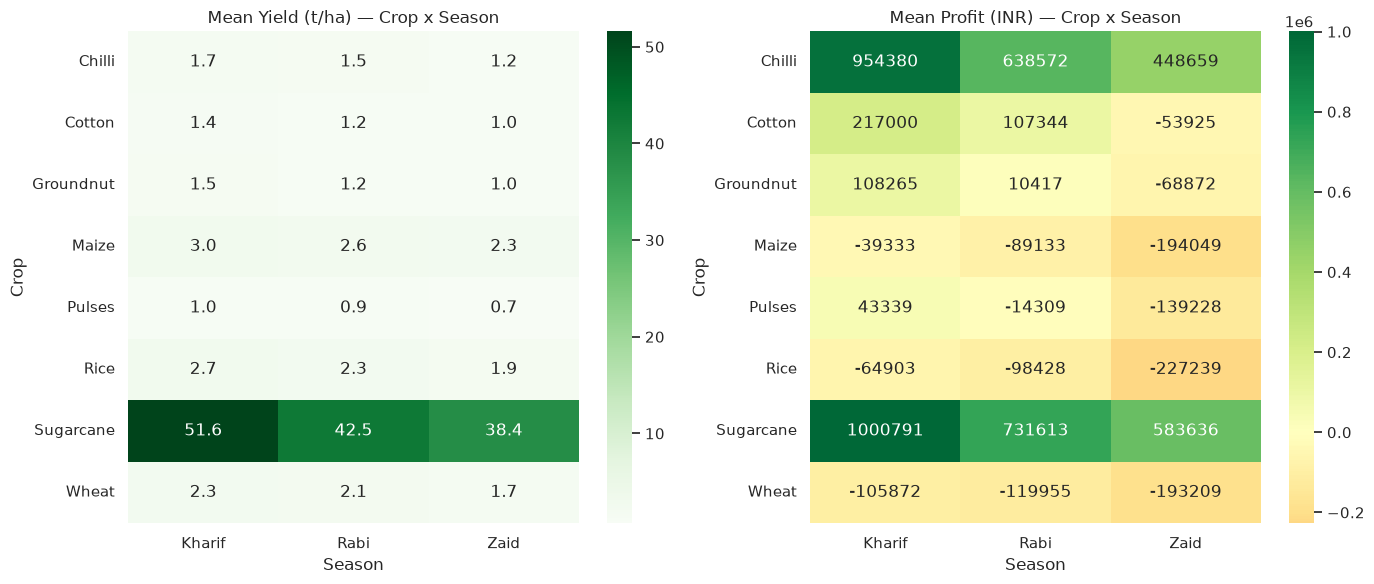

In [16]:
crop_season_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean', observed=True)
crop_season_profit = df.pivot_table(values='Profit_INR', index='Crop', columns='Season', aggfunc='mean', observed=True)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(crop_season_yield.round(1), annot=True, fmt='.1f', cmap='Greens', ax=axes[0])
axes[0].set_title('Mean Yield (t/ha) — Crop x Season')
sns.heatmap(crop_season_profit.round(0), annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=axes[1])
axes[1].set_title('Mean Profit (INR) — Crop x Season')
plt.tight_layout()
plt.show()


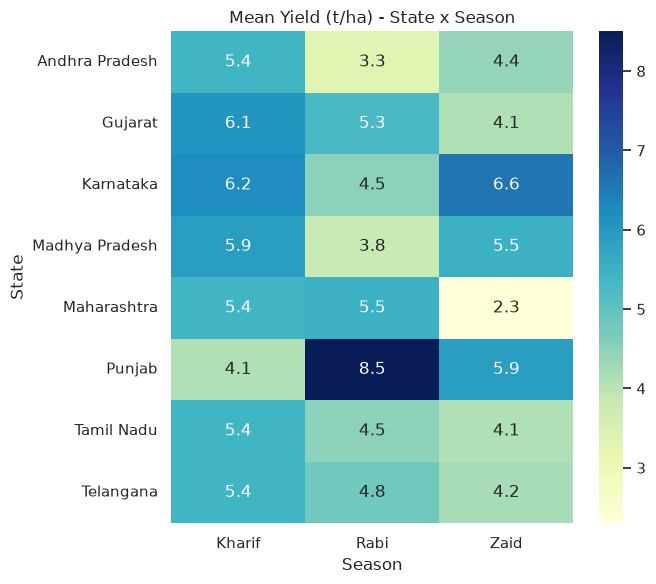

In [17]:
state_season_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='State', columns='Season', aggfunc='mean', observed=True)
fig ,ax = plt.subplots(figsize=(7,6))
sns.heatmap(state_season_yield.round(1) , annot=True, fmt = '.1f' , cmap = 'YlGnBu', ax=ax)
ax.set_title('Mean Yield (t/ha) - State x Season')
plt.tight_layout()
plt.show()

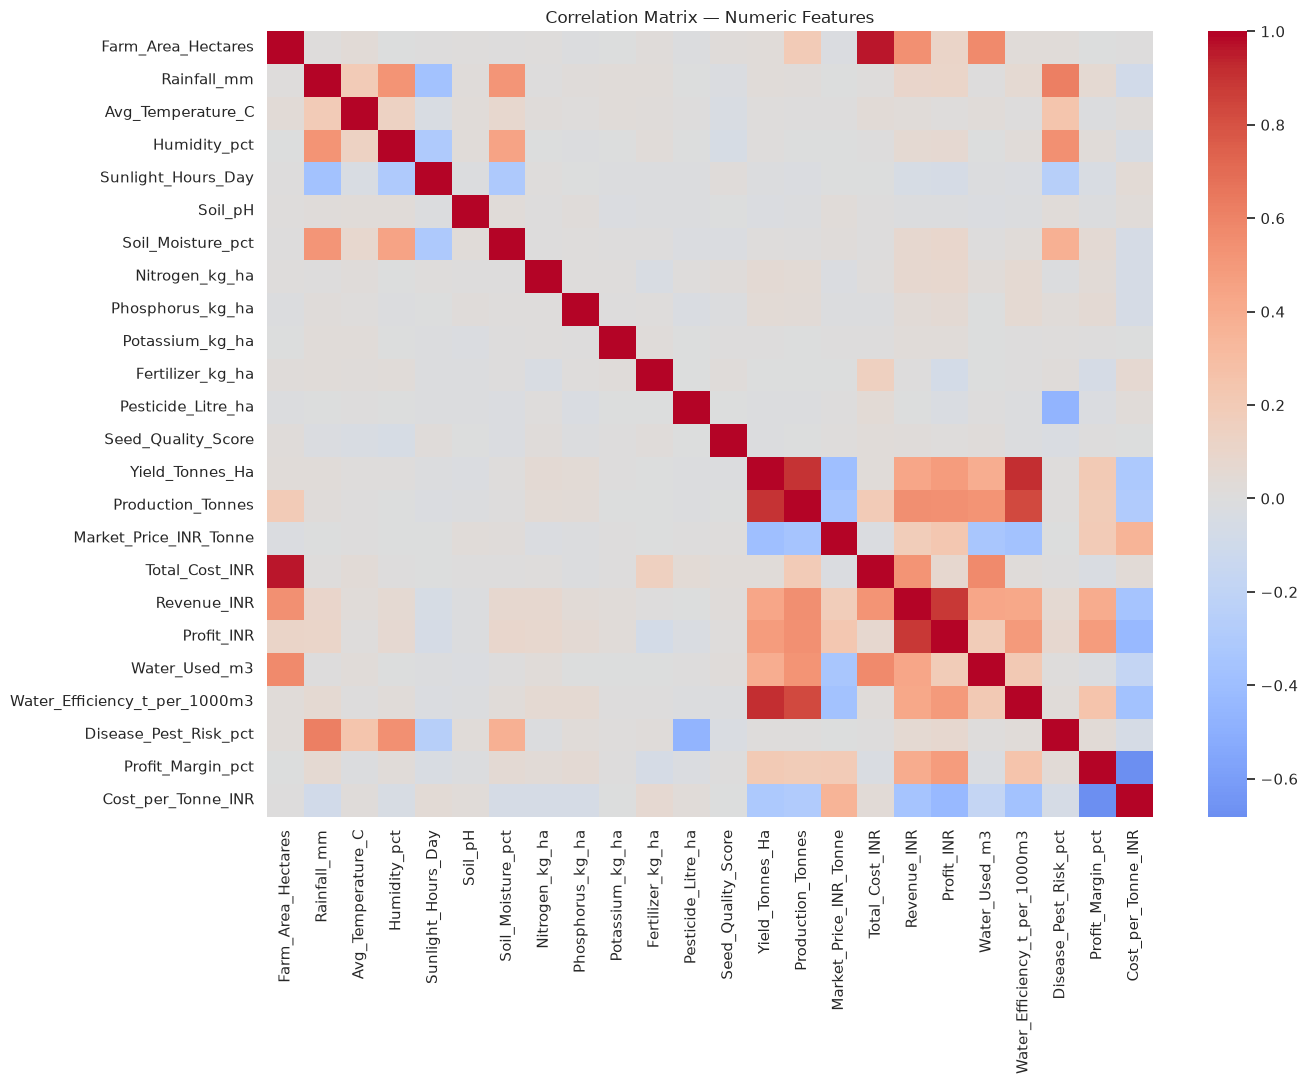

In [18]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14,11))
sns.heatmap(corr, annot = False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()




In [19]:
yield_corr = corr['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False)
profit_corr = corr['Profit_INR'].drop('Profit_INR').sort_values(key=abs, ascending=False)
 
print("Strongest correlates of Yield_Tonnes_Ha:")
print(yield_corr.head(8).round(3))
print("\nStrongest correlates of Profit_INR:")
print(profit_corr.head(8).round(3))


Strongest correlates of Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.913
Production_Tonnes                0.899
Profit_INR                       0.485
Revenue_INR                      0.430
Water_Used_m3                    0.392
Market_Price_INR_Tonne          -0.388
Cost_per_Tonne_INR              -0.318
Profit_Margin_pct                0.207
Name: Yield_Tonnes_Ha, dtype: float64

Strongest correlates of Profit_INR:
Revenue_INR                      0.887
Production_Tonnes                0.541
Water_Efficiency_t_per_1000m3    0.489
Yield_Tonnes_Ha                  0.485
Profit_Margin_pct                0.481
Cost_per_Tonne_INR              -0.428
Market_Price_INR_Tonne           0.225
Water_Used_m3                    0.190
Name: Profit_INR, dtype: float64


In [20]:
def group_by_season(col):
    return [df.loc[df['Season'] == s, col].dropna() for s in SEASON_ORDER]
 
for col in ['Yield_Tonnes_Ha', 'Profit_INR']:
    groups = group_by_season(col)
    f_stat, p_anova = stats.f_oneway(*groups)
    h_stat, p_kw = stats.kruskal(*groups)
    print(f"--- {col} ---")
    print(f"One-way ANOVA:      F = {f_stat:.3f}, p = {p_anova:.4g}")
    print(f"Kruskal-Wallis:      H = {h_stat:.3f}, p = {p_kw:.4g}")
    sig = "statistically significant" if p_kw < 0.05 else "not statistically significant"
    print(f"=> Seasonal difference in {col} is {sig} at alpha = 0.05\n")
 
 
# %%
contingency = pd.crosstab(df['Season'], df['Irrigation_Method'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p = {p_chi:.4g}")
sig = "statistically significant" if p_chi < 0.05 else "not statistically significant"
print(f"=> Association between Season and Irrigation_Method is {sig} at alpha = 0.05")
 


--- Yield_Tonnes_Ha ---
One-way ANOVA:      F = 1.269, p = 0.2812
Kruskal-Wallis:      H = 70.155, p = 5.835e-16
=> Seasonal difference in Yield_Tonnes_Ha is statistically significant at alpha = 0.05

--- Profit_INR ---
One-way ANOVA:      F = 34.292, p = 1.712e-15
Kruskal-Wallis:      H = 101.926, p = 7.363e-23
=> Seasonal difference in Profit_INR is statistically significant at alpha = 0.05

Chi-square = 3.51, dof = 6, p = 0.7423
=> Association between Season and Irrigation_Method is not statistically significant at alpha = 0.05


In [21]:
r_overall, p_overall = stats.pearsonr(df['Rainfall_mm'], df['Yield_Tonnes_Ha'])
print(f"Overall: r = {r_overall:.3f}, p = {p_overall:.4g}")
 
for s in SEASON_ORDER:
    sub = df[df['Season'] == s]
    r, p = stats.pearsonr(sub['Rainfall_mm'], sub['Yield_Tonnes_Ha'])
    print(f"{s}: r = {r:.3f}, p = {p:.4g}")
 
 


Overall: r = 0.027, p = 0.08514
Kharif: r = -0.015, p = 0.5184
Rabi: r = 0.037, p = 0.1365
Zaid: r = 0.047, p = 0.2566


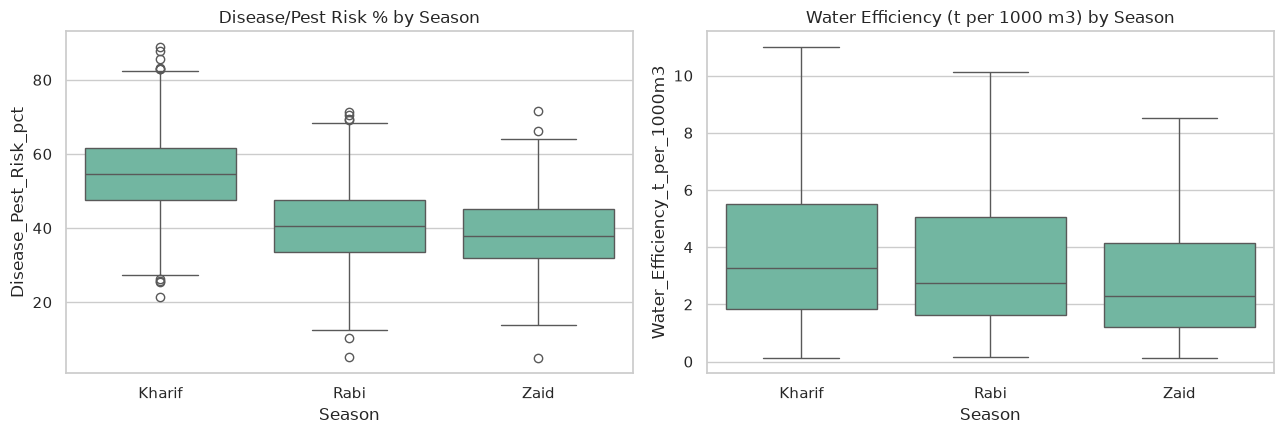

,Disease_Pest_Risk_pct,Water_Efficiency_t_per_1000m3
Season,,
Kharif,54.47,5.89
Rabi,40.48,5.19
Zaid,38.22,4.41


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER, ax=axes[0])
axes[0].set_title('Disease/Pest Risk % by Season')
sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=SEASON_ORDER, ax=axes[1], showfliers=False)
axes[1].set_title('Water Efficiency (t per 1000 m3) by Season')
plt.tight_layout()
plt.show()
 
df.groupby('Season', observed=True)[['Disease_Pest_Risk_pct', 'Water_Efficiency_t_per_1000m3']].mean().round(2)
 


In [23]:
# %%
best_yield_season = season_econ['Yield_Tonnes_Ha'].idxmax()
best_profit_season = season_econ['Profit_INR'].idxmax()
worst_profit_season = season_econ['Profit_INR'].idxmin()
highest_cost_season = season_econ['Total_Cost_INR'].idxmax()
top_yield_corr = yield_corr.index[0]
top_profit_corr = profit_corr.index[0]
 
print("KEY INSIGHTS")
print("=" * 60)
print(f"1. {best_yield_season} has the highest average yield "
      f"({season_econ.loc[best_yield_season, 'Yield_Tonnes_Ha']:.2f} t/ha), while "
      f"{season_econ['Yield_Tonnes_Ha'].idxmin()} has the lowest "
      f"({season_econ['Yield_Tonnes_Ha'].min():.2f} t/ha).")
print(f"2. {best_profit_season} delivers the strongest average profit "
      f"(INR {season_econ.loc[best_profit_season, 'Profit_INR']:,.0f}/farm), while "
      f"{worst_profit_season} performs worst on average "
      f"(INR {season_econ.loc[worst_profit_season, 'Profit_INR']:,.0f}/farm).")
print(f"3. Only {profitable_share.min():.1f}%-{profitable_share.max():.1f}% of farms are profitable "
      f"depending on the season -- roughly half of all farms in this dataset post a loss, "
      f"regardless of season.")
print(f"4. {highest_cost_season} carries the highest average production cost, which does not "
      f"always correspond to the highest average profit -- cost and profitability don't move together.")
print(f"5. Among all numeric factors, '{top_yield_corr}' has the strongest linear relationship with "
      f"yield (r = {yield_corr.iloc[0]:.2f}), and '{top_profit_corr}' has the strongest relationship "
      f"with profit (r = {profit_corr.iloc[0]:.2f}).")
print(f"6. The rainfall-yield relationship (overall r = {r_overall:.2f}) is weak, suggesting yield in "
      f"this dataset is driven more by inputs (fertilizer, seed quality, irrigation method) than by "
      f"rainfall alone.")
print(f"7. The seasonal differences in yield and profit found in Section 11 are "
      f"{'statistically significant' if p_kw < 0.05 else 'not statistically significant'} "
      f"(Kruskal-Wallis p = {p_kw:.4g}), meaning season is "
      f"{'a real driver of' if p_kw < 0.05 else 'not clearly linked to'} performance differences, "
      f"not just random noise.")
print(f"8. Irrigation method usage is "
      f"{'significantly associated' if p_chi < 0.05 else 'not significantly associated'} with season "
      f"(chi-square p = {p_chi:.4g}).")
 
 


KEY INSIGHTS
1. Kharif has the highest average yield (5.50 t/ha), while Zaid has the lowest (4.64 t/ha).
2. Kharif delivers the strongest average profit (INR 178,915/farm), while Zaid performs worst on average (INR -24,805/farm).
3. Only 36.0%-58.0% of farms are profitable depending on the season -- roughly half of all farms in this dataset post a loss, regardless of season.
4. Zaid carries the highest average production cost, which does not always correspond to the highest average profit -- cost and profitability don't move together.
5. Among all numeric factors, 'Water_Efficiency_t_per_1000m3' has the strongest linear relationship with yield (r = 0.91), and 'Revenue_INR' has the strongest relationship with profit (r = 0.89).
6. The rainfall-yield relationship (overall r = 0.03) is weak, suggesting yield in this dataset is driven more by inputs (fertilizer, seed quality, irrigation method) than by rainfall alone.
7. The seasonal differences in yield and profit found in Section 11 are 